In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey!!")
result

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hey!!". It\'s a greeting. We need to respond politely, maybe ask what they need. No special instructions. Just a friendly chat.'}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 73, 'total_tokens': 127, 'completion_time': 0.057475056, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.003558351, 'prompt_tokens_details': None, 'queue_time': 0.312101578, 'total_time': 0.061033407}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3023a70d60', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f833c-bac7-74e0-8a5a-d5941ab5b7bd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 54, 'total_tokens': 127, 'output_token_details': {'reasoning': 33}})

In [2]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

class Route(BaseModel):
    step: Literal["poem","story","joke"]=Field(description="The next step in routing process")

router = llm.with_structured_output(Route)

class State(TypedDict):
    input: str
    decision:str
    output:str


In [9]:
def Node1(state:State):
    """Writes a short story"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def Node3(state:State):
    """Writes a poem"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def Node2(state:State):
    """Writes a joke"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_router(state:State):
    """Route the input to the appropriate node"""
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke or poem based on the users' request"
            ),
            HumanMessage(
                content=state['input']
            )
        ]
    )
    return {"decision":decision.step}

def route_decision(state:State):
    if state['decision'] == "story":
        return "Node1"
    elif state['decision'] == "poem":
        return "Node2"
    elif state['decision'] == "joke":
        return "Node3"

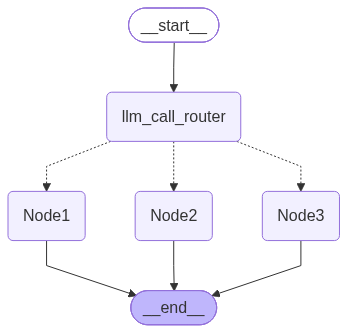

In [10]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(State)

graph.add_node("Node1", story_node)
graph.add_node("Node2", poem_node)
graph.add_node("Node3", joke_node)
graph.add_node("llm_call_router",llm_call_router)

graph.add_edge(START,"llm_call_router")
graph.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "Node1":"Node1",
        "Node2":"Node2",
        "Node3":"Node3"
    }
)
graph.add_edge("Node1",END)
graph.add_edge("Node2",END)
graph.add_edge("Node3",END)

build = graph.compile()

graph_img = build.get_graph().draw_mermaid_png()
display(Image(graph_img))

In [13]:
state=build.invoke({"input":"Write a story about AI Systems"})
print(state["output"])

Maya had never thought she’d find a secret in the humming heart of the city.

The skyline of Neon was a lattice of glass and steel, each building a node, each street a conduit. Above the traffic lights and the solar panels, invisible streams of data pulsed through fiber-optic veins, carrying instructions from the AI Core that kept the city alive. Every bus, every power line, every emergency response was choreographed by a network of AI systems, all speaking in a language of algorithms and probabilities.

She worked as a systems engineer for the Metropolitan Operations Network, a job that meant she was the human hand that kept the invisible machinery running. She’d spent her whole career learning the intricacies of the city’s neural network—how the Traffic AI predicted congestion, how the Health AI monitored vitals across the populace, how the Climate AI adjusted ventilation in the underground tunnels. It was a job she loved because it felt like she was part of something larger than her